In [ ]:
API TESTING:

In [16]:
import os
from pathlib import Path
from dotenv import load_dotenv
from google import genai

# 1. Provide the exact raw string path to your .env file
env_path = Path(r"C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\testingFiles\.env")

print(f"Target path: {env_path}")
print(f"Exists on disk: {env_path.exists()}")

if not env_path.exists():
    raise FileNotFoundError(f"File not found at: {env_path}")

# 2. Load the variables from the specified .env file
load_dotenv(dotenv_path=env_path)

# 3. Retrieve the key (checking common variable names)
api_key = (
    os.getenv("GEMINI_API_KEY")
    or os.getenv("GoogleAPI")
    or os.getenv("GOOGLE_API_KEY")
)

if not api_key:
    raise ValueError(
        f"The .env file was found, but no API key was detected inside it. "
        f"Make sure your .env contains a line like: GEMINI_API_KEY=AIzaSy..."
    )

print(f"API key successfully loaded (Starts with: {api_key[:6]}...)")

# 4. Initialize client & verify connection
client = genai.Client(api_key=api_key)

response = client.models.generate_content(
    model="gemini-3.6-flash", contents="Respond with: Connection verified."
)

print("\n--- Test Response ---")
print(response.text.strip())

Target path: C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\testingFiles\.env
Exists on disk: True
API key successfully loaded (Starts with: AQ.Ab8...)

--- Test Response ---
Connection verified.


## Image Testing

In [17]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.8 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.3 MB 3.6 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.3 MB 6.0 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.3 MB 7.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.3 MB 5.6 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.3 MB 5.0 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.3 MB 4.2 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 4.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 4.0 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 3.9 MB/s eta 0:00:01
   ------------------------------------- -- 8.7/9.3 MB 3.7 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


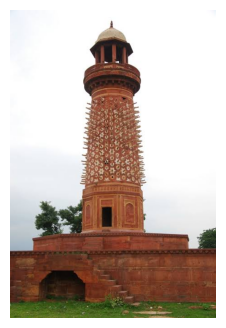

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. ', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}]}}

In [1]:
import os
from google.genai import types
from pathlib import Path
from dotenv import load_dotenv
from google import genai
from google.genai import types
import matplotlib.pyplot as plt
from PIL import Image
from pydantic import BaseModel, Field

# 1. Load your .env file
env_path = Path(r"C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\testingFiles\.env")
load_dotenv(dotenv_path=env_path)

api_key = (
    os.getenv("GEMINI_API_KEY")
    or os.getenv("GoogleAPI")
    or os.getenv("GOOGLE_API_KEY")
)

if not api_key:
    raise ValueError("API Key not found in .env file.")

client = genai.Client(api_key=api_key)


# 2. Define the exact response structure
class LandscapeLandmarkAnalysis(BaseModel):
    is_landmark_or_tourist_site: bool = Field(
        description="True if the image is a verified natural landscape, tourist attraction, or historical site in Pakistan. False if it's a random house, street, or modern generic building."
    )
    name: str = Field(
        default="Unknown",
        description="Official name of the place, valley, lake, fort, or landmark.",
    )
    location: str = Field(
        default="Unknown",
        description="City, District, Province/Region (e.g. Gilgit-Baltistan, KPK, Punjab, Sindh, Balochistan).",
    )
    landscape_type: str = Field(
        default="Unknown",
        description="Category (e.g. Mountain Lake, Historical Fort, Valley, Monument, Mosque, Pass).",
    )
    historical_background: str = Field(
        default="",
        description="Detailed historical origin, who built it or geological/natural history.",
    )
    why_famous: str = Field(
        default="",
        description="Key reasons why it is a prominent tourist spot or heritage location.",
    )


# 3. Path to your test image (replace with your file name/path)
image_path = "test_image_2.jfif"  # Place your picture in the same directory or provide full path

if not Path(image_path).exists():
    raise FileNotFoundError(
        f"Could not find image at {image_path}. Please place an image there."
    )

image = Image.open(image_path)

# Display the image inside the notebook
plt.figure(figsize=(6, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

# 4. Prompt for recognition and strict filtering
prompt = """
Analyze this image carefully.
Determine whether it is a recognized natural landscape, tourist destination, or historic/cultural landmark in Pakistan.

Rules:
1. If this is a generic house, private residential building, normal street, or unidentified modern structure, set 'is_landmark_or_tourist_site' to False.
2. If it is a recognized tourist site or historic landmark, set 'is_landmark_or_tourist_site' to True, and provide the official name, exact location, landscape type, comprehensive background history, and why it is famous.
"""

# # 5. Execute Multimodal Request
# response = client.models.generate_content(
#     model="gemini-3.6-flash",
#     contents=[image, prompt],
#     config=types.GenerateContentConfig(
#         response_mime_type="application/json",
#         response_schema=LandscapeLandmarkAnalysis,
#     ),
# )
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=[image, prompt],
    config=types.GenerateContentConfig(
        tools=[{"google_search": {}}],  # Enables web retrieval
        response_mime_type="application/json",
        response_schema=LandscapeLandmarkAnalysis,
    ),
)

# 6. Parse and format the result
result = LandscapeLandmarkAnalysis.model_validate_json(response.text)

print("=" * 60)
print("              LANDSCAPE & LANDMARK SCAN RESULT              ")
print("=" * 60)
print(f"📍 Recognized Site:     {result.is_landmark_or_tourist_site}")
print(f"🏷️  Name:                {result.name}")
print(f"🗺️  Location:            {result.location}")
print(f"🏞️  Type:                {result.landscape_type}")
print("-" * 60)
print(f"📜 Background History:\n{result.historical_background}")
print("-" * 60)
print(f"⭐ Why It's Famous:\n{result.why_famous}")
print("=" * 60)

---


## GROQ API

In [2]:
!pip install groq python-dotenv


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
from dotenv import load_dotenv
from groq import Groq

# Load variables from .env
load_dotenv()

api_key = os.getenv("GROQ_API_KEY")

if not api_key:
    raise ValueError(
        "GROQ_API_KEY not found. "
        "Make sure your .env file exists and contains the API key."
    )

print("API key loaded successfully.")
print(f"Testing model: qwen/qwen3.6-27b")

try:
    # Create Groq client
    client = Groq(api_key=api_key)

    # Send a test request
    completion = client.chat.completions.create(
        model="qwen/qwen3.6-27b",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an expert Pakistan travel planner. "
                    "Give clear, practical, concise answers."
                ),
            },
            {
                "role": "user",
                "content": (
                    "Plan a 5-day trip from Islamabad to Hunza. "
                    "The traveler likes mountains, photography, local food, "
                    "and cultural places. Give a day-by-day plan."
                ),
            },
        ],
        temperature=0.7,
        max_completion_tokens=1500,
    )

    result = completion.choices[0].message.content

    print("\n" + "=" * 60)
    print("API TEST SUCCESSFUL!")
    print("=" * 60)
    print("\nMODEL RESPONSE:\n")
    print(result)

except Exception as e:
    print("\n" + "=" * 60)
    print("API TEST FAILED!")
    print("=" * 60)
    print(f"\nERROR: {type(e).__name__}")
    print(f"DETAILS: {e}")

API key loaded successfully.
Testing model: qwen/qwen3.6-27b

API TEST SUCCESSFUL!

MODEL RESPONSE:


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Duration:** 5 days
   - **Route:** Islamabad to Hunza
   - **Interests:** Mountains, photography, local food, cultural places
   - **Output Format:** Day-by-day plan
   - **Role:** Expert Pakistan travel planner
   - **Tone/Style:** Clear, practical, concise

2.  **Key Constraints & Considerations:**
   - **Travel Time:** Islamabad to Hunza (Karimabad) is typically a 10-14 hour drive via Karakoram Highway (KKH). It's usually split into 2 days for comfort and safety, especially considering road conditions and altitude.
   - **Day 1:** Islamabad to Naran/Chilas (overnight)
   - **Day 2:** Chilas to Karimabad/Hunza (overnight)
   - **Day 3:** Hunza Valley exploration (mountains, photography, culture)
   - **Day 4:** Hunza excursions (Baltit/Altit forts, Passu, Attabad Lake, photography spots)
   - **Day 5:** Return jou

In [8]:
import os
from pathlib import Path
from dotenv import dotenv_values, load_dotenv
import edge_tts
from google import genai
from google.genai import types
from groq import Groq
from IPython.display import Audio, display
from pydantic import BaseModel, Field

# 1. Load keys safely from your backend .env file
env_path = Path(r"C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\backend\.env")
load_dotenv(dotenv_path=env_path, override=True)
env_dict = dotenv_values(dotenv_path=env_path)

groq_key = (
    os.getenv("GROQ_API_KEY_TripPlan")
    or os.getenv("GROQ_API_KEY")
    or env_dict.get("GROQ_API_KEY_TripPlan")
)
gemini_key = (
    os.getenv("GEMINI_API_KEY")
    or os.getenv("GoogleAPI")
    or os.getenv("GOOGLE_API_KEY")
    or env_dict.get("GEMINI_API_KEY")
    or env_dict.get("GoogleAPI")
)

if not groq_key or not gemini_key:
    raise ValueError(
        f"Missing keys! Groq: {'OK' if groq_key else 'Missing'}, Gemini: {'OK' if gemini_key else 'Missing'}"
    )

# 2. Initialize Clients
groq_client = Groq(api_key=groq_key)
gemini_client = genai.Client(api_key=gemini_key)


# 3. Schema
class TranslationOutput(BaseModel):
    detected_language: str = Field(description="Detected source language.")
    english_translation: str = Field(description="Natural English translation.")
    urdu_translation: str = Field(
        description="Authentic Urdu translation in Nastaliq/Arabic script (اردو)."
    )


# 4. Processing Functions
def transcribe_audio_file(audio_path: str) -> str:
    print(f"\n[1/3] 🎙️ Transcribing audio file...")
    with open(audio_path, "rb") as file:
        transcription = groq_client.audio.transcriptions.create(
            file=(Path(audio_path).name, file.read()),
            model="whisper-large-v3",
            response_format="json",
        )
    return transcription.text


def translate_to_en_and_ur(text: str) -> TranslationOutput:
    print(f"\n[2/3] 🌐 Translating text via Gemini...")
    prompt = f"""
    You are a multilingual translator for travelers in Pakistan.
    Analyze the following input text:
    "{text}"

    1. Detect the source language.
    2. Provide an accurate and natural English translation.
    3. Provide an authentic Urdu translation in proper Urdu script (اردو).
    """
    response = gemini_client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=TranslationOutput,
        ),
    )
    return TranslationOutput.model_validate_json(response.text)


async def generate_speech_file(
    text: str, voice: str, filename: str
) -> str:
    if not text.strip():
        return ""
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(filename)
    return filename


# 5. Master Pipeline
async def run_translator_pipeline(
    input_text: str = None, audio_path: str = None
):
    print("=" * 65)
    print("        MULTILINGUAL TRANSLATOR & SPEECH ENGINE       ")
    print("=" * 65)

    if audio_path and Path(audio_path).exists():
        raw_text = transcribe_audio_file(audio_path)
        print(f"✅ Original Transcript: \"{raw_text}\"")
    elif input_text:
        raw_text = input_text
        print(f"📝 Text Input: \"{raw_text}\"")
    else:
        raw_text = "Bonjour! Comment puis-je aller au fort de Lahore?"
        print(f"ℹ️ Default sample: \"{raw_text}\"")

    # Translate
    result = translate_to_en_and_ur(raw_text)

    print("\n" + "-" * 65)
    print(f"🌍 Detected Language:   {result.detected_language}")
    print(f"🇬🇧 English Translation: {result.english_translation}")
    print(f"🇵🇰 Urdu Translation:    {result.urdu_translation}")
    print("-" * 65)

    # Generate Neural Audio
    print("\n[3/3] 🔊 Synthesizing Audio (TTS)...")
    en_audio = "output_en.mp3"
    ur_audio = "output_ur.mp3"

    await generate_speech_file(
        result.english_translation, "en-US-ChristopherNeural", en_audio
    )
    await generate_speech_file(
        result.urdu_translation, "ur-PK-UzmaNeural", ur_audio
    )

    print(f"✅ English audio: {Path(en_audio).resolve()}")
    print(f"✅ Urdu audio:    {Path(ur_audio).resolve()}")
    print("=" * 65)

    # Inline Audio Players in Notebook
    print("\n🎧 Listen to English:")
    display(Audio(en_audio))
    print("🎧 Listen to Urdu:")
    display(Audio(ur_audio))


# 6. Direct Jupyter Execution
audio_target = r"C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\testingFiles\classroom-german.mp3"
await run_translator_pipeline(audio_path=audio_target)

        MULTILINGUAL TRANSLATOR & SPEECH ENGINE       

[1/3] 🎙️ Transcribing audio file...


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


✅ Original Transcript: " Im Klassenzimmer. Die Tafel. Der Lehrer. Die Lehrerin. Der Tisch. Der Stuhl. Das Buch. Das Heft. Das Mäppchen. Der Computer."

[2/3] 🌐 Translating text via Gemini...

-----------------------------------------------------------------
🌍 Detected Language:   German
🇬🇧 English Translation: In the classroom. The board. The male teacher. The female teacher. The table. The chair. The book. The notebook. The pencil case. The computer.
🇵🇰 Urdu Translation:    کلاس روم میں۔ بورڈ۔ استاد۔ استانی۔ میز۔ کرسی۔ کتاب۔ کاپی۔ پنسل کیس۔ کمپیوٹر۔
-----------------------------------------------------------------

[3/3] 🔊 Synthesizing Audio (TTS)...
✅ English audio: C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\testingFiles\output_en.mp3
✅ Urdu audio:    C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\testingFiles\output_ur.mp3

🎧 Listen to English:


🎧 Listen to Urdu:


In [ ]:
import os
from pathlib import Path
from dotenv import dotenv_values, load_dotenv
import edge_tts
from google import genai
from google.genai import types
from groq import Groq
from IPython.display import Audio, display
from pydantic import BaseModel, Field

# ==============================================================================
# 🛠️ CONFIGURATION & FILE PATHS (EDIT HERE FOR FUTURE TESTING)
# ==============================================================================

# 1. Path to your .env file
ENV_PATH = Path(r"C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\backend\.env")

# 2. Path to the audio file you want to test
#    👉 CHANGE THIS PATH ANY TIME YOU HAVE A NEW AUDIO FILE:
TEST_AUDIO_FILE = Path(
    r"C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\testingFiles\clinstructions.mp3"
)

# 3. Output directory for generated MP3 files
OUTPUT_DIR = Path(
    r"C:\Users\msn\Desktop\Bon_Voyage_Pakistan_Qoder\testingFiles"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# 🔑 CLIENT INITIALIZATION
# ==============================================================================

load_dotenv(dotenv_path=ENV_PATH, override=True)
env_dict = dotenv_values(dotenv_path=ENV_PATH)

groq_key = (
    os.getenv("GROQ_API_KEY_TripPlan")
    or os.getenv("GROQ_API_KEY")
    or env_dict.get("GROQ_API_KEY_TripPlan")
)
gemini_key = (
    os.getenv("GEMINI_API_KEY")
    or os.getenv("GoogleAPI")
    or os.getenv("GOOGLE_API_KEY")
    or env_dict.get("GEMINI_API_KEY")
    or env_dict.get("GoogleAPI")
)

if not groq_key or not gemini_key:
    raise ValueError(
        f"Missing API keys! Groq: {'✅ Found' if groq_key else '❌ Missing'}, "
        f"Gemini: {'✅ Found' if gemini_key else '❌ Missing'}"
    )

groq_client = Groq(api_key=groq_key)
gemini_client = genai.Client(api_key=gemini_key)


# ==============================================================================
# 📋 STRUCTURED OUTPUT SCHEMA
# ==============================================================================


class TranslationResult(BaseModel):
    detected_source_language: str = Field(
        description="Source language detected (e.g., German, French, Arabic, Chinese, Spanish)."
    )
    english_translation: str = Field(
        description="Natural, accurate English translation."
    )
    urdu_translation: str = Field(
        description="Authentic Urdu translation in Nastaliq / Arabic script (اردو)."
    )


# ==============================================================================
# ⚙️ CORE PROCESSING FUNCTIONS
# ==============================================================================


def transcribe_voice(file_path: Path) -> str:
    """Extracts raw text from any audio file using Groq Whisper."""
    print(f"\n[1/3] 🎙️ Transcribing: {file_path.name}...")
    with open(file_path, "rb") as f:
        transcription = groq_client.audio.transcriptions.create(
            file=(file_path.name, f.read()),
            model="whisper-large-v3",
            response_format="json",
        )
    return transcription.text.strip()


def translate_text(input_text: str) -> TranslationResult:
    """Translates text to English and Urdu using Gemini 3.6 Flash."""
    print(f"\n[2/3] 🌐 Translating via Gemini 3.6 Flash...")
    prompt = f"""
    You are a multilingual translator for travelers and tourists in Pakistan.
    Analyze the following input text:
    "{input_text}"

    Tasks:
    1. Detect the source language.
    2. Provide an accurate and natural English translation.
    3. Provide an authentic, grammatically correct Urdu translation in proper Urdu script (اردو).
    """
    response = gemini_client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=TranslationResult,
        ),
    )
    return TranslationResult.model_validate_json(response.text)


async def synthesize_voice(text: str, voice: str, output_path: Path) -> Path:
    """Generates an MP3 audio file using Edge-TTS neural voices."""
    if not text.strip():
        return output_path
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(str(output_path))
    return output_path


# ==============================================================================
# 🚀 TEST RUNNER FUNCTIONS
# ==============================================================================


async def test_audio_translation(audio_path: Path):
    """Pipeline 1: Audio Input -> STT -> Translation -> Audio Files"""
    print("=" * 70)
    print("                 PIPELINE 1: AUDIO FILE TRANSLATION                 ")
    print("=" * 70)

    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found at: {audio_path}")

    # 1. Transcribe Audio
    raw_transcript = transcribe_voice(audio_path)
    print(f"📝 Original Transcript:\n   \"{raw_transcript}\"")

    # 2. Translate to English & Urdu
    result = translate_text(raw_transcript)

    print("\n" + "-" * 70)
    print(f"🌍 Detected Language:   {result.detected_source_language}")
    print(f"🇬🇧 English Translation: {result.english_translation}")
    print(f"🇵🇰 Urdu Translation:    {result.urdu_translation}")
    print("-" * 70)

    # 3. Generate Spoken Output Files
    print("\n[3/3] 🔊 Synthesizing Neural Audio Files...")
    en_audio = OUTPUT_DIR / f"{audio_path.stem}_translated_english.mp3"
    ur_audio = OUTPUT_DIR / f"{audio_path.stem}_translated_urdu.mp3"

    await synthesize_voice(
        result.english_translation, "en-US-ChristopherNeural", en_audio
    )
    await synthesize_voice(
        result.urdu_translation, "ur-PK-UzmaNeural", ur_audio
    )

    print(f"✅ Saved English Voice: {en_audio}")
    print(f"✅ Saved Urdu Voice:    {ur_audio}")
    print("=" * 70)

    # Play inline in Jupyter
    try:
        print("\n🎧 Spoken English:")
        display(Audio(str(en_audio)))
        print("🎧 Spoken Urdu:")
        display(Audio(str(ur_audio)))
    except Exception:
        pass


async def test_text_translation(
    user_text: str, output_prefix: str = "text_test"
):
    """Pipeline 2: User Typed Text -> Translation -> Audio Files"""
    print("=" * 70)
    print("                 PIPELINE 2: TEXT INPUT TRANSLATION                 ")
    print("=" * 70)
    print(f"📥 Input Text: \"{user_text}\"")

    # 1. Translate
    result = translate_text(user_text)

    print("\n" + "-" * 70)
    print(f"🌍 Detected Language:   {result.detected_source_language}")
    print(f"🇬🇧 English Translation: {result.english_translation}")
    print(f"🇵🇰 Urdu Translation:    {result.urdu_translation}")
    print("-" * 70)

    # 2. Generate Audio Files
    print("\n🔊 Synthesizing Neural Audio Files...")
    en_audio = OUTPUT_DIR / f"{output_prefix}_english.mp3"
    ur_audio = OUTPUT_DIR / f"{output_prefix}_urdu.mp3"

    await synthesize_voice(
        result.english_translation, "en-US-ChristopherNeural", en_audio
    )
    await synthesize_voice(
        result.urdu_translation, "ur-PK-UzmaNeural", ur_audio
    )

    print(f"✅ Saved English Voice: {en_audio}")
    print(f"✅ Saved Urdu Voice:    {ur_audio}")
    print("=" * 70)

    # Play inline in Jupyter
    try:
        print("\n🎧 Spoken English:")
        display(Audio(str(en_audio)))
        print("🎧 Spoken Urdu:")
        display(Audio(str(ur_audio)))
    except Exception:
        pass



await test_audio_translation(TEST_AUDIO_FILE)

# Test with French, German, Arabic, Turkish, Chinese, etc.
sample_query = "Bonjour, où se trouve l'arrêt de bus pour aller à Murree?"
await test_text_translation(sample_query)